# Loading Documents with LangChain

This notebook demonstrates how to load PDF documents (like the **Mamba-3** paper in your `data/` folder) into LangChain `Document` objects using standard loaders.

### 1. Prerequisites
Ensure you have the required packages installed in your environment. Since we are parsing PDFs, `pymupdf` is highly recommended for its speed and metadata extraction capabilities.

In [1]:
# %pip install pymupdf langchain-community

### 2. Load the Local PDF Document
We use `PyMuPDFLoader` because it is extremely fast and retrieves rich metadata (author, title, creation date, etc.) directly from the PDF headers.

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

# Define the path to the PDF document
pdf_path = "data/mamba 3.pdf"

# Initialize the loader
loader = PyMuPDFLoader(pdf_path)

# Load the document pages
docs = loader.load()

print(f"Successfully loaded {len(docs)} pages from: {pdf_path}")

C:\Users\XRIG\AppData\Local\Temp\ipykernel_3688\3919052503.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader
g:\Pretarined model -tsting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded 31 pages from: data/mamba 3.pdf


### 3. Inspect the Document Structure and Metadata
Each page is loaded as a separate `Document` object containing `page_content` and a `metadata` dictionary.

In [3]:
import json

# Fetch the first page document
first_page = docs[0]

# Print metadata in a readable JSON format
print("Metadata structure for Page 1:")
print(json.dumps(first_page.metadata, indent=4))

print("\n" + "="*50 + "\n")

# Print the first 800 characters of the text content
print("Page 1 Text Content Preview:")
print(first_page.page_content[:800] + "...")

Metadata structure for Page 1:
{
    "producer": "pikepdf 8.15.1",
    "creator": "arXiv GenPDF (tex2pdf:8e18bb9)",
    "creationdate": "",
    "source": "data/mamba 3.pdf",
    "file_path": "data/mamba 3.pdf",
    "total_pages": 31,
    "format": "PDF 1.5",
    "title": "Mamba-3: Improved Sequence Modeling using State Space Principles",
    "author": "Aakash Lahoti; Kevin Y. Li; Berlin Chen; Caitlin Wang; Aviv Bick; J. Zico Kolter; Tri Dao; Albert Gu",
    "subject": "",
    "keywords": "",
    "moddate": "",
    "trapped": "",
    "modDate": "",
    "creationDate": "",
    "page": 0
}


Page 1 Text Content Preview:
Mamba-3: Improved Sequence Modeling using State Space Principles
Aakash Lahoti ∗1, Kevin Y. Li ∗1, Berlin Chen ∗2, Caitlin Wang ∗2, Aviv Bick
1, J. Zico Kolter
1,
Tri Dao†23, and Albert Gu†14
1Carnegie Mellon University
2Princeton University
3Together AI
4Cartesia AI
{alahoti, kyl2, abick, zkolter, agu}@cs.cmu.edu
{bc2188, caitlinwang, tridao}@princeton.edu
Abstract
Scalin

# uysing summarizer

In [4]:
from transformers import pipeline

# create pipeline
summarizer = pipeline(
    task="summarization",
    model="sshleifer/distilbart-cnn-12-6",
    device=0
)

# extract text from loaded document
text = docs[0].page_content

# summarize
summary = summarizer(
    text,
    max_length=150,
    min_length=40,
    do_sample=False
)

print(summary)

Device set to use cuda:0


[{'summary_text': ' Mamba-3: Improved Sequence Modeling using State Space Principles . Advances inference-time scaling can unlock new capabilities in AI systems . Advises the development of sub-quadratic models with reduced linear compute and constant memory requirements .'}]


In [5]:
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader, TextLoader

all_docs = []

# 1. Load all PDF files using PyMuPDFLoader
pdf_loader = DirectoryLoader(
    path="data",
    glob="*.pdf",
    loader_cls=PyMuPDFLoader
)
all_docs.extend(pdf_loader.load())

# 2. Load all plain text files using TextLoader (specifying UTF-8 encoding)
text_loader = DirectoryLoader(
    path="data",
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={"encoding": "utf-8"}
)
all_docs.extend(text_loader.load())

print(f"Total documents successfully loaded: {len(all_docs)}")


Total documents successfully loaded: 31


In [6]:
# Loop through the loaded documents and print their details
for index, doc in enumerate(all_docs):
    # Retrieve file source and page number from metadata
    source_file = doc.metadata.get("source", "Unknown Source")
    page_number = doc.metadata.get("page", 0)  # PDFs have page numbers, text files do not
    
    print(f"--- Document #{index + 1} ---")
    print(f"Source: {source_file}")
    if "page" in doc.metadata:
        print(f"Page: {page_number + 1}")
        
    print(f"Metadata: {doc.metadata}")
    print("\nContent Preview (First 500 characters):")
    # Print the content preview, replacing newlines with spaces for clean printing
    preview_content = doc.page_content[:500].replace('\n', ' ')
    print(preview_content)
    print("=" * 60 + "\n")


--- Document #1 ---
Source: data\mamba 3.pdf
Page: 1
Metadata: {'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:8e18bb9)', 'creationdate': '', 'source': 'data\\mamba 3.pdf', 'file_path': 'data\\mamba 3.pdf', 'total_pages': 31, 'format': 'PDF 1.5', 'title': 'Mamba-3: Improved Sequence Modeling using State Space Principles', 'author': 'Aakash Lahoti; Kevin Y. Li; Berlin Chen; Caitlin Wang; Aviv Bick; J. Zico Kolter; Tri Dao; Albert Gu', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}

Content Preview (First 500 characters):
Mamba-3: Improved Sequence Modeling using State Space Principles Aakash Lahoti ∗1, Kevin Y. Li ∗1, Berlin Chen ∗2, Caitlin Wang ∗2, Aviv Bick 1, J. Zico Kolter 1, Tri Dao†23, and Albert Gu†14 1Carnegie Mellon University 2Princeton University 3Together AI 4Cartesia AI {alahoti, kyl2, abick, zkolter, agu}@cs.cmu.edu {bc2188, caitlinwang, tridao}@princeton.edu Abstract Scaling inference-time compu

In [7]:
# reminder to iclude sleep so thaat APi deosnt timeout

import wikipedia
import json

# Articles to load
articles = [
    "Artificial intelligence",
    "Artificial general intelligence",
    "Superintelligence"
]

# Final JSON list
wikidocs = []

for article in articles:

    try:

        # Fetch article content
        content = wikipedia.page(article).content

        # Store in JSON format
        wikidocs.append({
            "title": article,
            "content": content
        })

        print(f"Loaded: {article}")

    except Exception as e:

        print(f"Failed: {article}")
        print(e)

# Pretty JSON output
print(json.dumps(wikidocs, indent=4))

Loaded: Artificial intelligence
Loaded: Artificial general intelligence
Loaded: Superintelligence
[
    {
        "title": "Artificial intelligence",
        "content": "Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.\nHigh-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.\nThe traditional goals of AI research 

In [8]:
wikidocs

[{'title': 'Artificial intelligence',
  'content': 'Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.\nHigh-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.\nThe traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well 

# what uses i can do
    1) The LLM can identify and update state values for the articles to fetch(not using LLM tokens much and this loader can fetch documents from the wikipedia) it will help me save tokens

# now i will focus on chunking

In [ ]:
#charactertextsplitter with overlap
import logging
#hidewarnings 
#logging.getLogger("langchain_text_spiltters").setLevel(logging.ERROR)
from langchain_text_splitters import CharacterTextSplitter

Text_splitter = CharacterTextSplitter(chunk_size =256,chunk_overlap =50,separator ="\n")


Final_chunk_list =[]

for doc in wikidocs:
    chunks = Text_splitter.split_text(doc["content"])

    #storing chunks with metadata

    for chunk in chunks:
        Final_chunk_list.append({"title":doc["title"],"content":chunk})


# Total_chunks
print(f"Total no of chunks is :{len(Final_chunk_list)}")

print(Final_chunk_list[0])

Created a chunk of size 492, which is longer than the specified 256
Created a chunk of size 297, which is longer than the specified 256
Created a chunk of size 687, which is longer than the specified 256
Created a chunk of size 828, which is longer than the specified 256
Created a chunk of size 299, which is longer than the specified 256
Created a chunk of size 300, which is longer than the specified 256
Created a chunk of size 396, which is longer than the specified 256
Created a chunk of size 386, which is longer than the specified 256
Created a chunk of size 640, which is longer than the specified 256
Created a chunk of size 445, which is longer than the specified 256
Created a chunk of size 747, which is longer than the specified 256
Created a chunk of size 444, which is longer than the specified 256
Created a chunk of size 531, which is longer than the specified 256
Created a chunk of size 383, which is longer than the specified 256
Created a chunk of size 459, which is longer tha

Total no of chunks is :395
{'title': 'Artificial intelligence', 'content': 'Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.'}


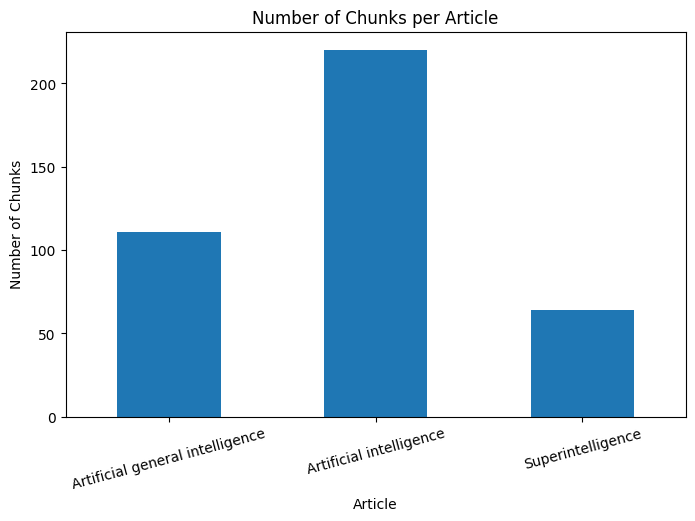

In [18]:
# chunk distribution

import pandas as pd

import matplotlib.pyplot as plt 
df = pd.DataFrame(Final_chunk_list)

df["Chunk_length"] = df["content"].apply(len)

# 1. Chunks per article
# -----------------------------

chunk_counts = df.groupby("title").size()

plt.figure(figsize=(8,5))
chunk_counts.plot(kind="bar")

plt.title("Number of Chunks per Article")
plt.xlabel("Article")
plt.ylabel("Number of Chunks")

plt.xticks(rotation=15)

plt.show()




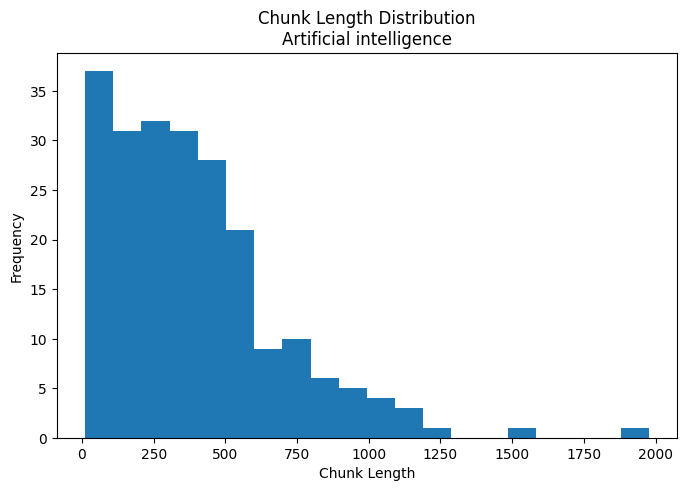

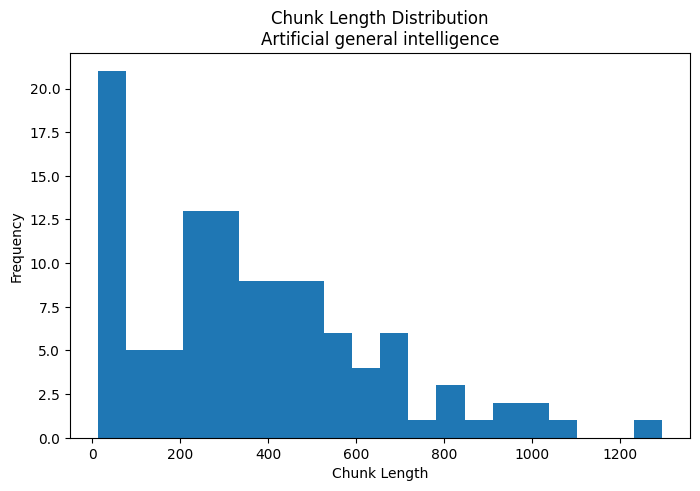

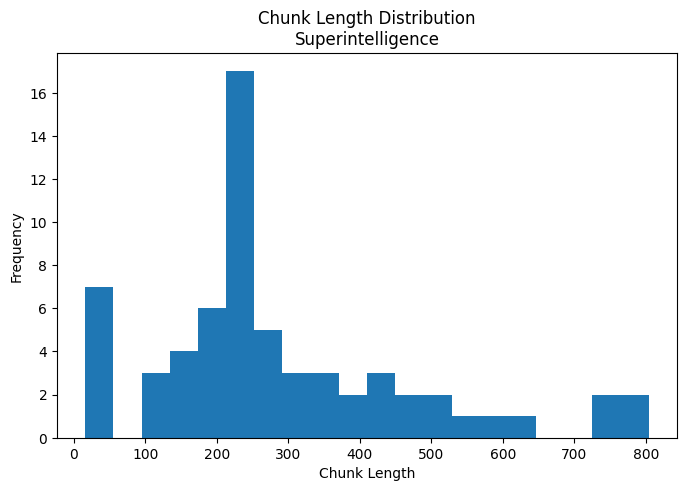

In [20]:

# Create chunk length column
df["chunk_length"] = df["content"].apply(len)

# -----------------------------------
# Chunk length distribution
# -----------------------------------

for title in df["title"].unique():

    plt.figure(figsize=(8,5))

    article_data = df[df["title"] == title]

    plt.hist(article_data["chunk_length"], bins=20)

    plt.title(f"Chunk Length Distribution\n{title}")

    plt.xlabel("Chunk Length")

    plt.ylabel("Frequency")

    plt.show()